# DiT-mini Parity Rep2 — Training Dynamics

Analyze the `_rep2` series: DiT-mini (384/6/6), N=4096, D=36, all 8 group sizes (G=2,3,4,6,9,12,18,36), 1M steps.

**Metrics logged via TensorBoard:**
- `Training/Loss` — batch DSM loss
- `Eval/PerGroup_Accuracy` — fraction of per-group parity checks correct
- `Eval/Sample_Accuracy` — fraction of samples where ALL groups pass
- `Eval/Sample_Mem_Ratio` — fraction of generated samples that exactly match training set
- `Eval/BitGroup_Mem_Ratio` — fraction of bit-groups matching training set
- `Eval/NaN_Ratio` — fraction of samples with NaN/invalid bits
- `Eval/GradNorm` — gradient norm at eval step

**Sections:**
1. Load all TB data
2. Per-G trajectory plots (loss, sample acc, group acc, memorization)
3. All-G overlay: sample accuracy & memorization vs log-step
4. Time-heatmap: x=log-step, y=G, color=metric
5. Final summary bar charts
6. Group acc vs sample acc scatter trajectory

In [1]:
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
from scipy.interpolate import interp1d

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
# ── Configuration ──────────────────────────────────────────────────────────
SAVEROOT = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
OUTDIR   = "../figures/parity_rep2_dynamics"
SAVE_FIGS = True

G_VALUES = [2, 3, 4, 6, 9, 12, 18, 36]
EXP_TEMPLATE = "DiT_mini_parity_N4096_D36_G{g}_even_rep2"
THRESHOLD = 0.80

os.makedirs(OUTDIR, exist_ok=True)

## 1. Load All TensorBoard Data

In [3]:
def load_tb(exp_dir):
    """Load all scalar tags from TensorBoard event dir. Returns dict tag -> (steps, vals) ndarrays."""
    ea = EventAccumulator(os.path.join(exp_dir, 'tensorboard'))
    ea.Reload()
    return {
        tag: (
            np.array([e.step  for e in ea.Scalars(tag)]),
            np.array([e.value for e in ea.Scalars(tag)]),
        )
        for tag in ea.Tags()['scalars']
    }

all_data = {}
for g in G_VALUES:
    exp_dir = os.path.join(SAVEROOT, EXP_TEMPLATE.format(g=g))
    try:
        all_data[g] = load_tb(exp_dir)
        last  = all_data[g]['Training/Loss'][0][-1]
        sa    = all_data[g]['Eval/Sample_Accuracy'][1][-1]
        mem   = all_data[g]['Eval/Sample_Mem_Ratio'][1][-1]
        print(f"G={g:2d}: last_step={last:>7d}  sample_acc={sa:.4f}  sample_mem={mem:.4f}")
    except Exception as e:
        print(f"G={g:2d}: FAILED — {e}")

G= 2: last_step=1000000  sample_acc=0.9951  sample_mem=0.6763


G= 3: last_step=1000000  sample_acc=0.9878  sample_mem=0.3936


G= 4: last_step=1000000  sample_acc=0.9609  sample_mem=0.3003


G= 6: last_step=1000000  sample_acc=0.9199  sample_mem=0.2588


G= 9: last_step=1000000  sample_acc=0.4619  sample_mem=0.4268


G=12: last_step=1000000  sample_acc=0.4365  sample_mem=0.3584


G=18: last_step=1000000  sample_acc=0.5728  sample_mem=0.4429


G=36: last_step=1000000  sample_acc=0.6558  sample_mem=0.3711


## 2. Per-G Trajectory Plots

4-panel per G: Loss | Sample+Group Accuracy | Memorization | GradNorm

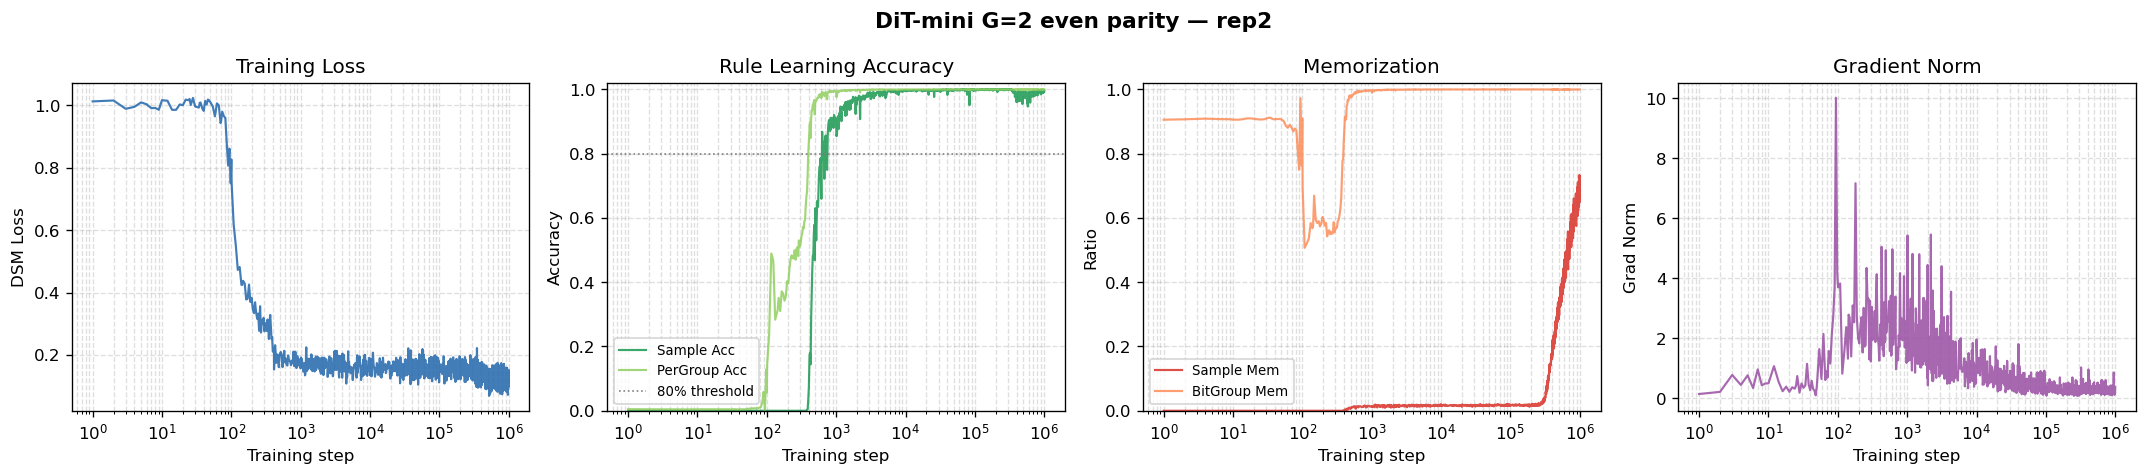

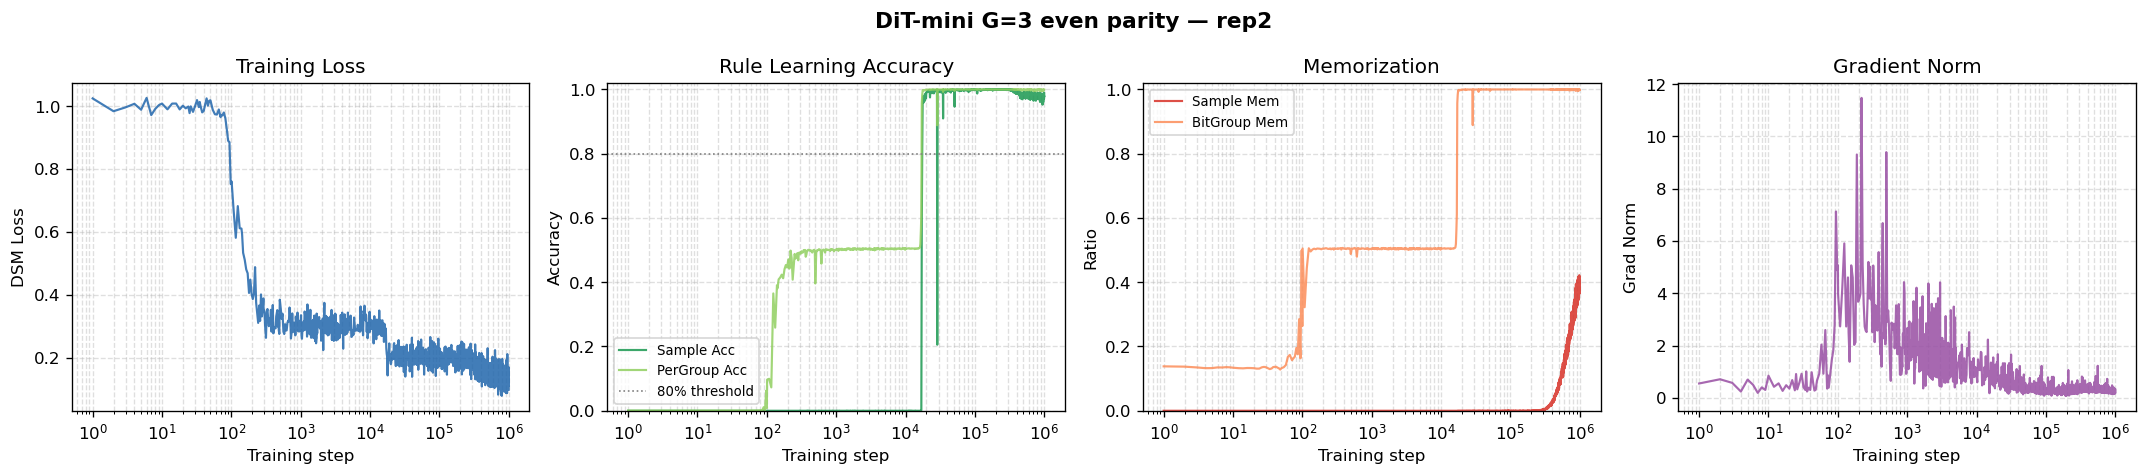

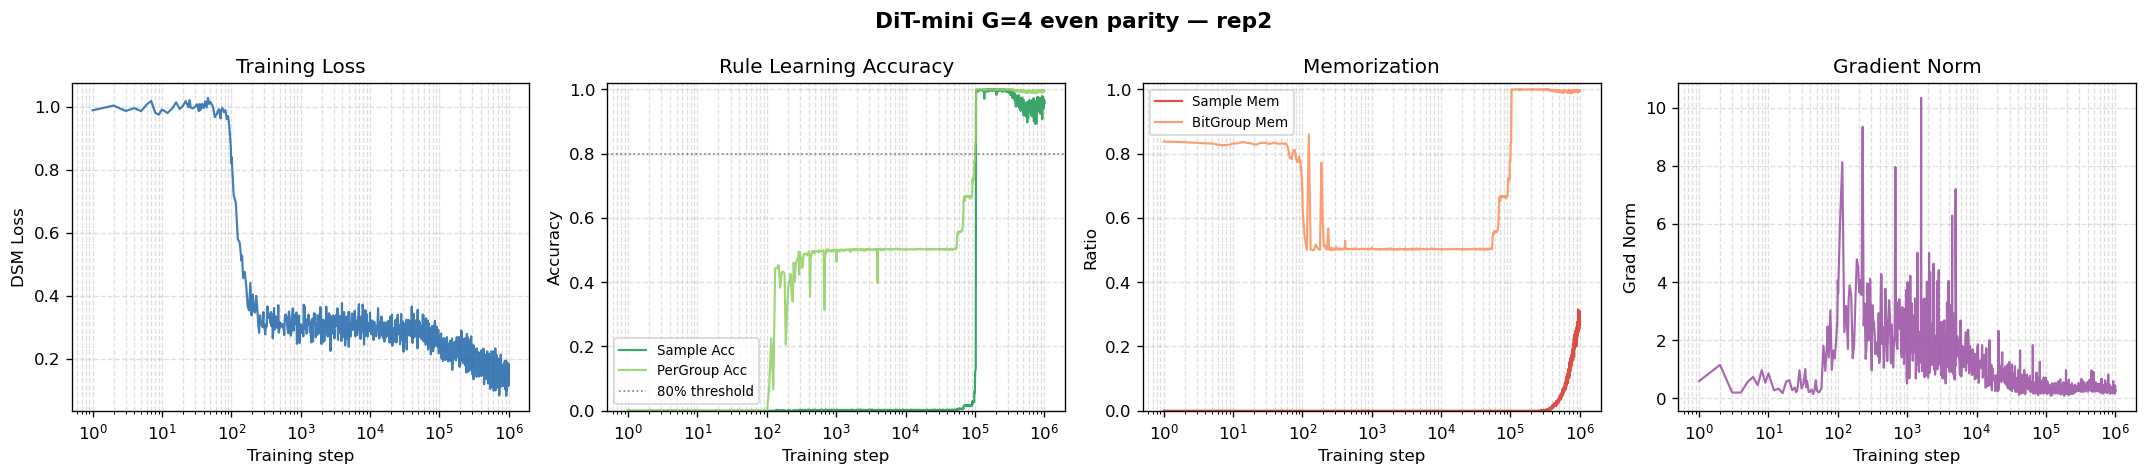

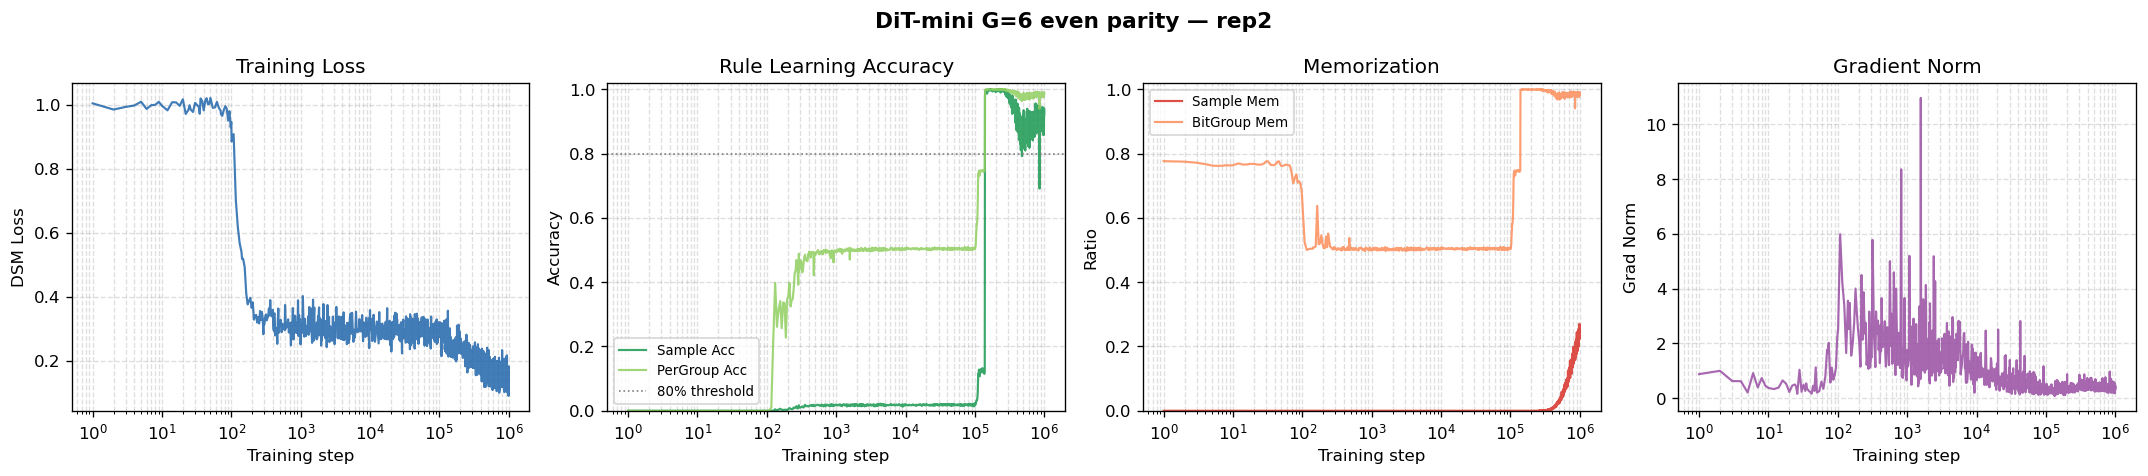

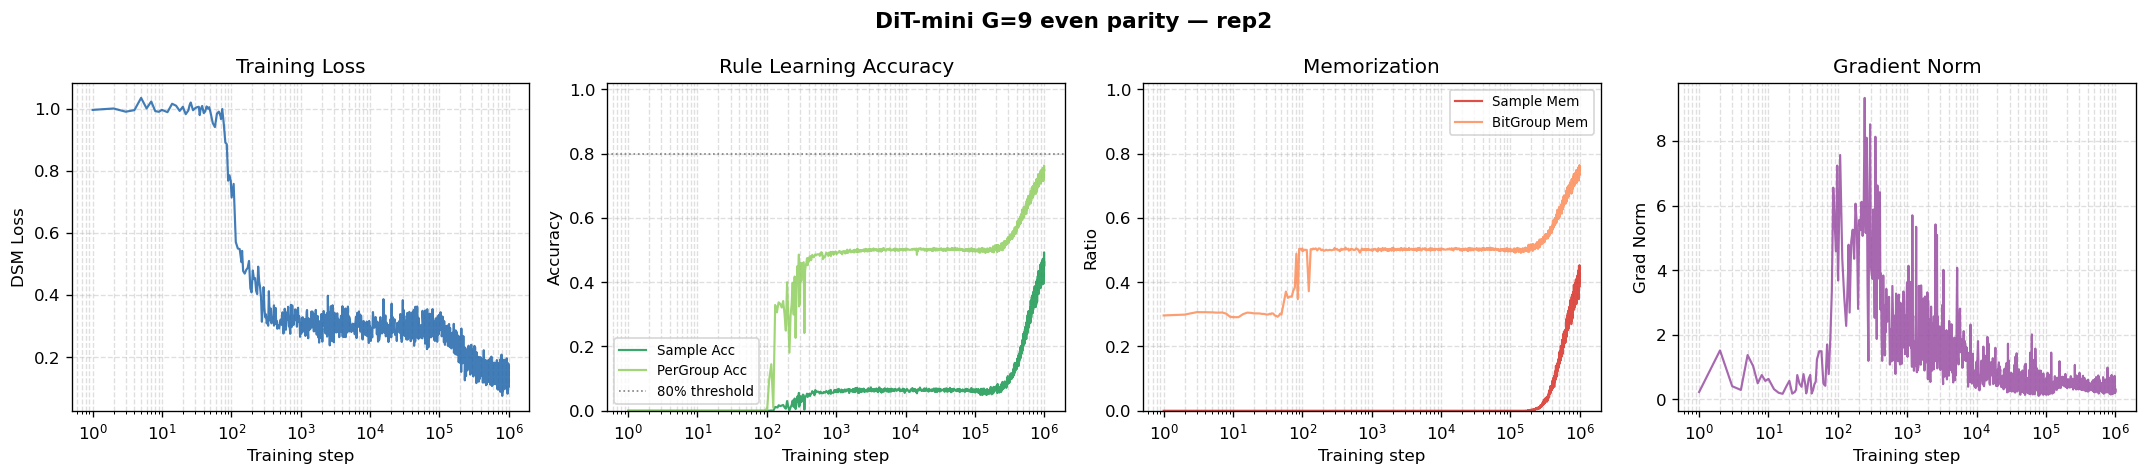

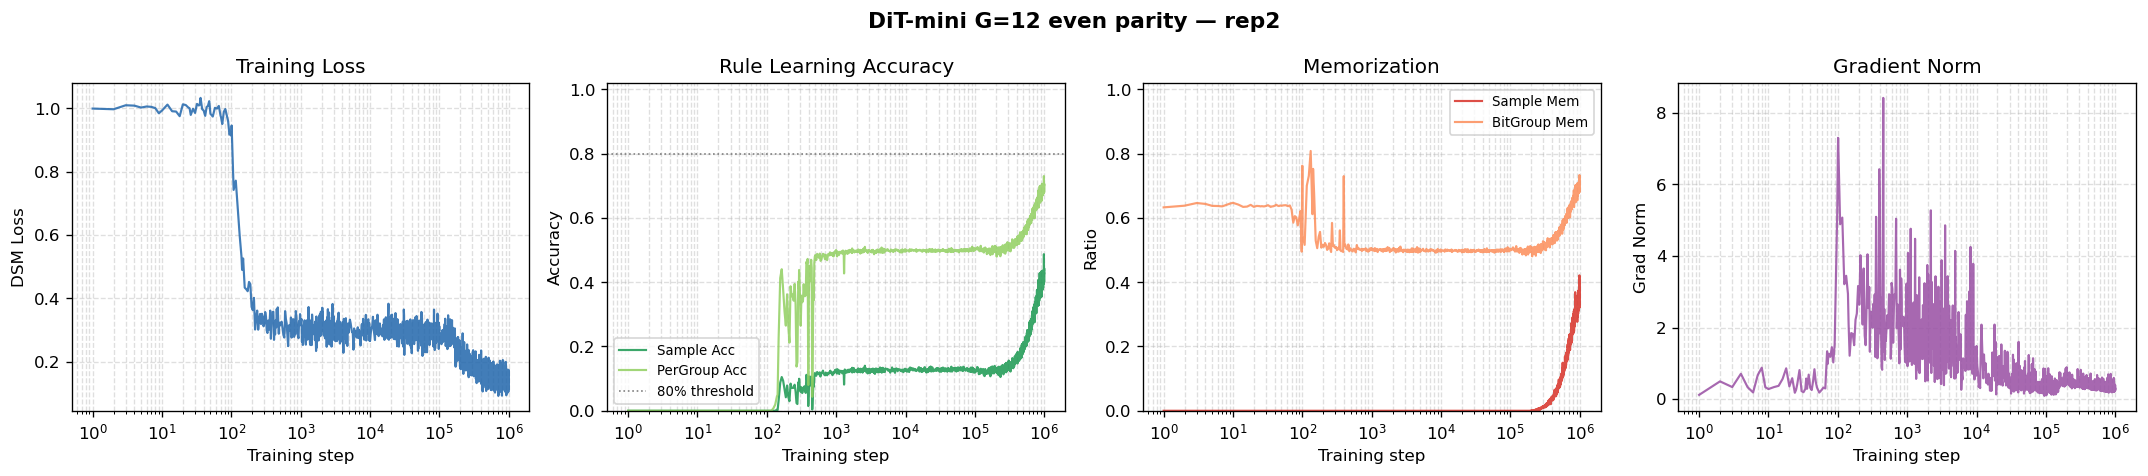

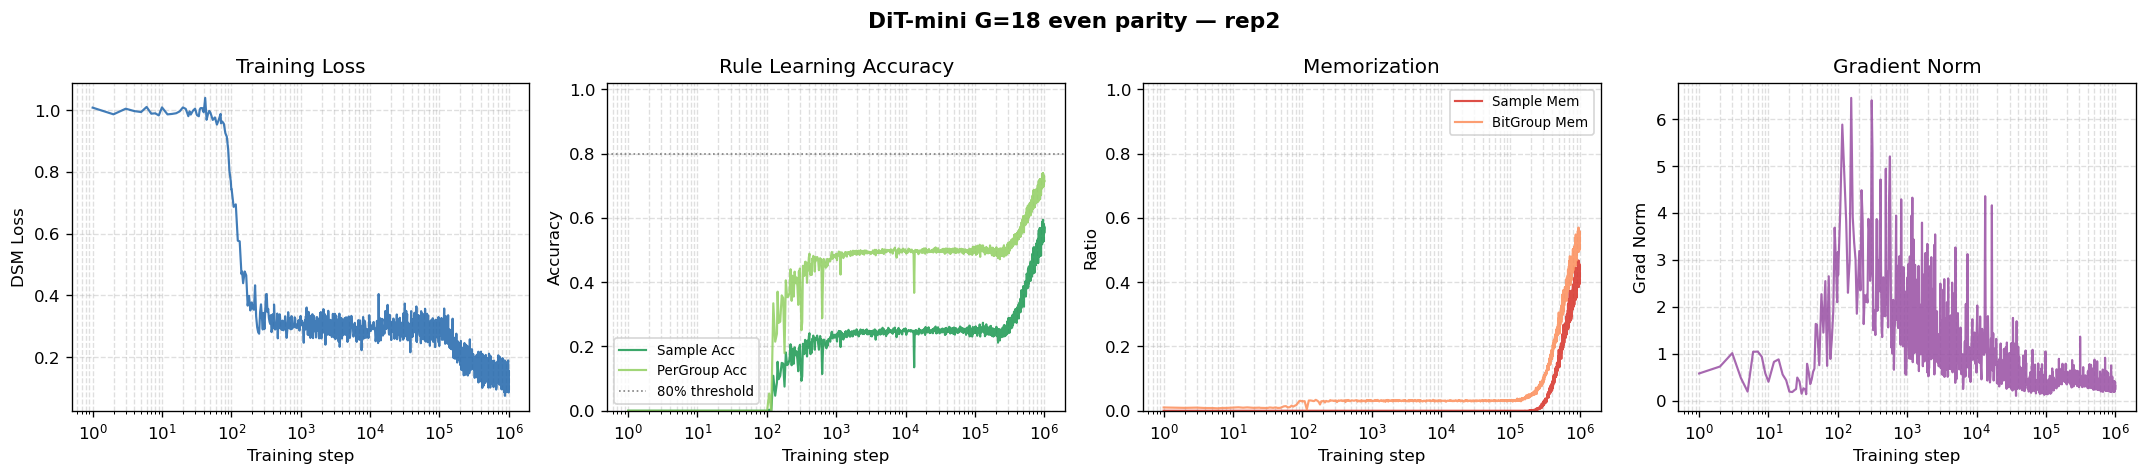

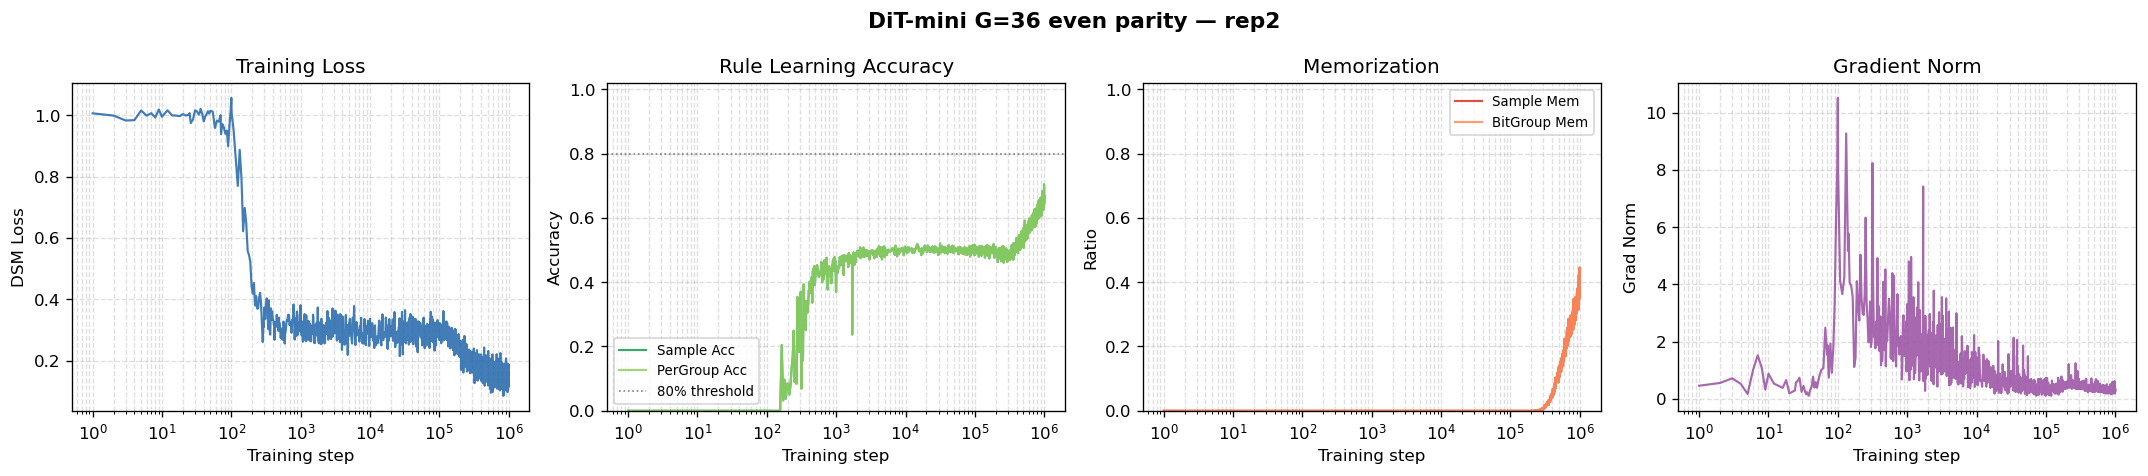

In [4]:
def plot_trajectory(g, data, save=False):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f'DiT-mini G={g} even parity — rep2', fontsize=13, fontweight='bold')

    def logplot(ax, tag, color, ylabel, ylim=None, label=None):
        if tag not in data: return
        steps, vals = data[tag]
        ax.plot(steps, vals, color=color, lw=1.3, alpha=0.85, label=label or tag.split('/')[-1])
        ax.set_xscale('log'); ax.set_xlabel('Training step'); ax.set_ylabel(ylabel)
        if ylim: ax.set_ylim(*ylim)
        ax.grid(True, which='both', ls='--', alpha=0.4)

    # Loss
    logplot(axes[0], 'Training/Loss', '#2166ac', 'DSM Loss')
    axes[0].set_title('Training Loss')

    # Accuracy
    logplot(axes[1], 'Eval/Sample_Accuracy',   '#1a9850', 'Accuracy', (0, 1.02), 'Sample Acc')
    logplot(axes[1], 'Eval/PerGroup_Accuracy',  '#91cf60', 'Accuracy', (0, 1.02), 'PerGroup Acc')
    axes[1].axhline(0.8, color='gray', ls=':', lw=1, label='80% threshold')
    axes[1].set_title('Rule Learning Accuracy'); axes[1].legend(fontsize=8)

    # Memorization
    logplot(axes[2], 'Eval/Sample_Mem_Ratio',   '#d73027', 'Ratio', (0, 1.02), 'Sample Mem')
    logplot(axes[2], 'Eval/BitGroup_Mem_Ratio', '#fc8d59', 'Ratio', (0, 1.02), 'BitGroup Mem')
    axes[2].set_title('Memorization'); axes[2].legend(fontsize=8)

    # GradNorm
    logplot(axes[3], 'Eval/GradNorm', '#984ea3', 'Grad Norm')
    axes[3].set_title('Gradient Norm')

    plt.tight_layout()
    if save:
        path = os.path.join(OUTDIR, f'trajectory_G{g:02d}.png')
        fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()

for g in G_VALUES:
    if g in all_data:
        plot_trajectory(g, all_data[g], save=SAVE_FIGS)

## 3. All-G Overlay

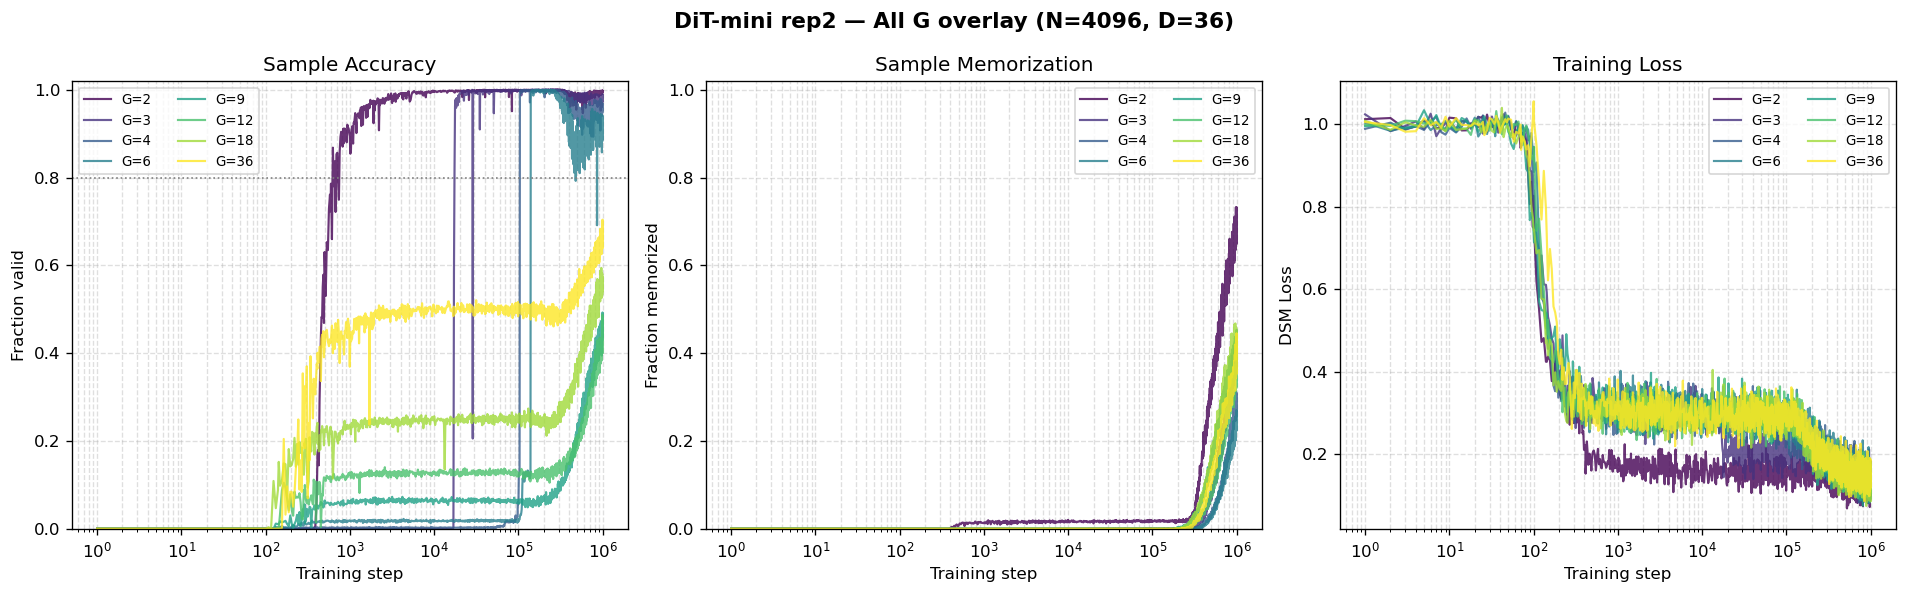

In [5]:
cmap   = plt.cm.viridis
colors = {g: cmap(i / (len(G_VALUES) - 1)) for i, g in enumerate(G_VALUES)}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('DiT-mini rep2 — All G overlay (N=4096, D=36)', fontsize=13, fontweight='bold')

for g in G_VALUES:
    if g not in all_data: continue
    d, c, lbl = all_data[g], colors[g], f'G={g}'

    for ax, tag in zip(axes, ['Eval/Sample_Accuracy', 'Eval/Sample_Mem_Ratio', 'Training/Loss']):
        if tag in d:
            ax.plot(*d[tag], color=c, lw=1.3, alpha=0.8, label=lbl)

labels_ylims = [
    ('Sample Accuracy',    'Fraction valid',      (0, 1.02)),
    ('Sample Memorization','Fraction memorized',   (0, 1.02)),
    ('Training Loss',      'DSM Loss',             None),
]
for ax, (title, ylabel, ylim) in zip(axes, labels_ylims):
    ax.set_xscale('log'); ax.set_xlabel('Training step')
    ax.set_ylabel(ylabel); ax.set_title(title)
    if ylim: ax.set_ylim(*ylim)
    ax.grid(True, which='both', ls='--', alpha=0.4)
    ax.legend(fontsize=8, ncol=2)

axes[0].axhline(0.8, color='gray', ls=':', lw=1)

plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(os.path.join(OUTDIR, 'all_G_overlay.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Time-Heatmap: x = log-step, y = G, color = metric

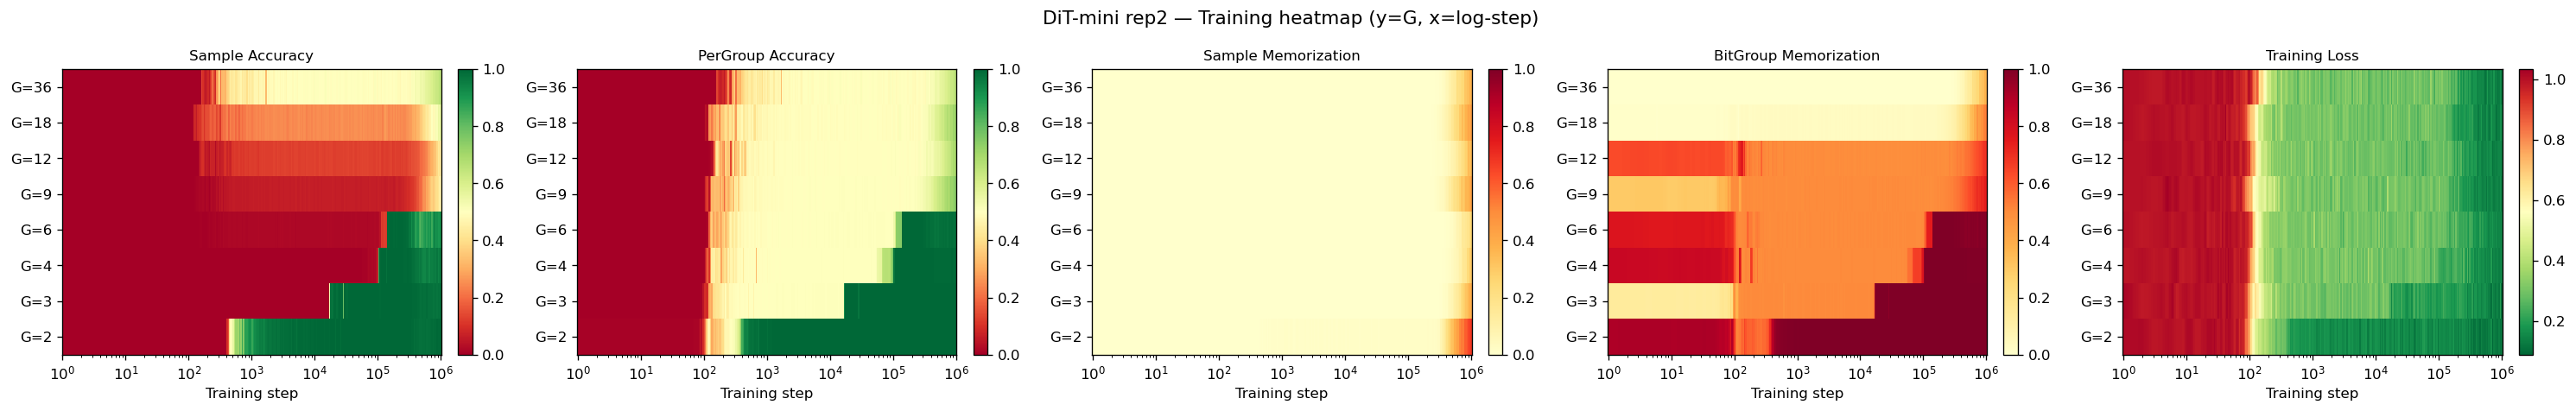

In [6]:
log_steps = np.logspace(0, 6, 300)

def make_heatmap_matrix(tag, vmin=None, vmax=None):
    mat = []
    for g in G_VALUES:
        if g not in all_data or tag not in all_data[g]:
            mat.append(np.full(len(log_steps), np.nan))
            continue
        steps, vals = all_data[g][tag]
        f   = interp1d(steps, vals, bounds_error=False, fill_value=(vals[0], vals[-1]))
        row = f(log_steps)
        if vmin is not None and vmax is not None:
            row = np.clip(row, vmin, vmax)
        mat.append(row)
    return np.array(mat)

metrics = [
    ("Eval/Sample_Accuracy",   "Sample Accuracy",       "RdYlGn",   0, 1),
    ("Eval/PerGroup_Accuracy", "PerGroup Accuracy",     "RdYlGn",   0, 1),
    ("Eval/Sample_Mem_Ratio",  "Sample Memorization",   "YlOrRd",   0, 1),
    ("Eval/BitGroup_Mem_Ratio","BitGroup Memorization", "YlOrRd",   0, 1),
    ("Training/Loss",          "Training Loss",         "RdYlGn_r", None, None),
]

fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4))
fig.suptitle("DiT-mini rep2 — Training heatmap (y=G, x=log-step)", fontsize=13)

for ax, (tag, title, cmap_name, vmin, vmax) in zip(axes, metrics):
    mat = make_heatmap_matrix(tag, vmin, vmax)
    im  = ax.pcolormesh(
        log_steps, np.arange(len(G_VALUES)), mat,
        cmap=cmap_name, vmin=vmin, vmax=vmax, shading="nearest"
    )
    ax.set_xscale("log")
    ax.set_xlabel("Training step")
    ax.set_yticks(np.arange(len(G_VALUES)))
    ax.set_yticklabels([f"G={g}" for g in G_VALUES])
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(os.path.join(OUTDIR, "timeheatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Final Summary — Steps to 80% + Final Metrics

In [7]:
summary = []
for g in G_VALUES:
    if g not in all_data: continue
    d = all_data[g]

    def final(tag):
        return d[tag][1][-1] if tag in d else np.nan

    steps_to_thresh = np.nan
    if 'Eval/Sample_Accuracy' in d:
        steps, vals = d['Eval/Sample_Accuracy']
        idx = np.where(vals >= THRESHOLD)[0]
        if len(idx): steps_to_thresh = steps[idx[0]]

    summary.append(dict(
        G=g,
        steps_to_thresh=steps_to_thresh,
        final_loss=final('Training/Loss'),
        final_sample_acc=final('Eval/Sample_Accuracy'),
        final_group_acc=final('Eval/PerGroup_Accuracy'),
        final_sample_mem=final('Eval/Sample_Mem_Ratio'),
        final_group_mem=final('Eval/BitGroup_Mem_Ratio'),
    ))

print(f"{'G':>4}  {'→80%':>10}  {'SampleAcc':>10}  {'GroupAcc':>10}  {'SampleMem':>10}  {'GroupMem':>10}  {'Loss':>8}")
print('-' * 72)
for s in summary:
    stt = f"{s['steps_to_thresh']:.0f}" if not np.isnan(s['steps_to_thresh']) else '>1M'
    print(f"{s['G']:>4}  {stt:>10}  {s['final_sample_acc']:>10.4f}  {s['final_group_acc']:>10.4f}  "
          f"{s['final_sample_mem']:>10.4f}  {s['final_group_mem']:>10.4f}  {s['final_loss']:>8.4f}")

   G        →80%   SampleAcc    GroupAcc   SampleMem    GroupMem      Loss
------------------------------------------------------------------------
   2         628      0.9951      0.9997      0.6763      0.9999    0.1212
   3       17424      0.9878      0.9990      0.3936      0.9992    0.0988
   4      104096      0.9609      0.9956      0.3003      0.9957    0.1487
   6      139936      0.9199      0.9865      0.2588      0.9876    0.1465
   9         >1M      0.4619      0.7476      0.4268      0.7490    0.1263
  12         >1M      0.4365      0.7026      0.3584      0.7044    0.1396
  18         >1M      0.5728      0.7283      0.4429      0.5498    0.1540
  36         >1M      0.6558      0.6558      0.3711      0.3711    0.1250


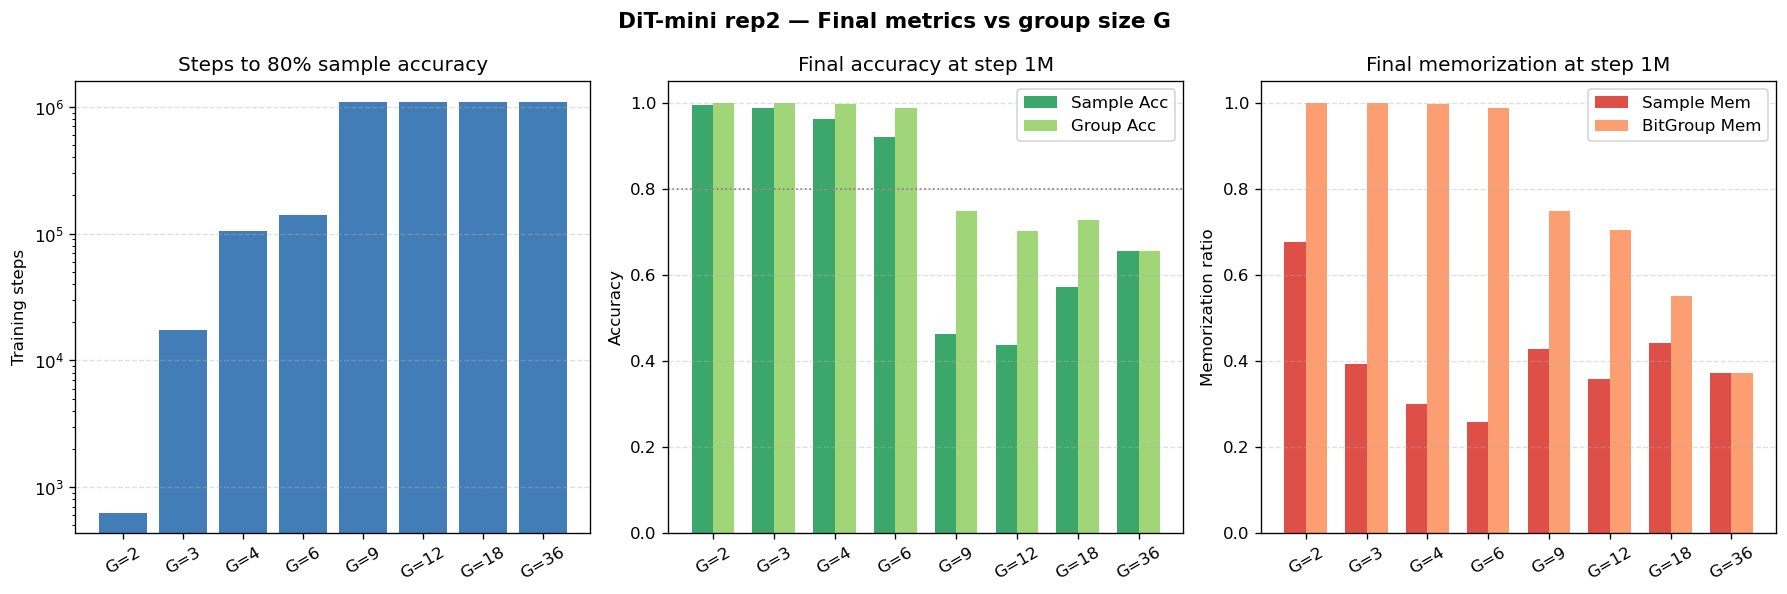

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('DiT-mini rep2 — Final metrics vs group size G', fontsize=13, fontweight='bold')

Gs = [s['G'] for s in summary]
x  = np.arange(len(Gs))
w  = 0.35
xtick_kw = dict(xticks=x, xticklabels=[f'G={g}' for g in Gs])

# Steps to threshold
ax = axes[0]
stt = [s['steps_to_thresh'] if not np.isnan(s['steps_to_thresh']) else 1.1e6 for s in summary]
ax.bar(x, stt, color='#2166ac', alpha=0.85)
ax.set(**xtick_kw); ax.tick_params(axis='x', rotation=30)
ax.set_yscale('log'); ax.set_ylabel('Training steps')
ax.set_title(f'Steps to {THRESHOLD*100:.0f}% sample accuracy')
ax.grid(True, axis='y', ls='--', alpha=0.4)

# Final accuracy
ax = axes[1]
ax.bar(x - w/2, [s['final_sample_acc'] for s in summary], w, label='Sample Acc', color='#1a9850', alpha=0.85)
ax.bar(x + w/2, [s['final_group_acc']  for s in summary], w, label='Group Acc',  color='#91cf60', alpha=0.85)
ax.set(**xtick_kw); ax.tick_params(axis='x', rotation=30)
ax.set_ylim(0, 1.05); ax.set_ylabel('Accuracy')
ax.set_title('Final accuracy at step 1M')
ax.axhline(0.8, color='gray', ls=':', lw=1)
ax.legend(); ax.grid(True, axis='y', ls='--', alpha=0.4)

# Final memorization
ax = axes[2]
ax.bar(x - w/2, [s['final_sample_mem'] for s in summary], w, label='Sample Mem',   color='#d73027', alpha=0.85)
ax.bar(x + w/2, [s['final_group_mem']  for s in summary], w, label='BitGroup Mem', color='#fc8d59', alpha=0.85)
ax.set(**xtick_kw); ax.tick_params(axis='x', rotation=30)
ax.set_ylim(0, 1.05); ax.set_ylabel('Memorization ratio')
ax.set_title('Final memorization at step 1M')
ax.legend(); ax.grid(True, axis='y', ls='--', alpha=0.4)

plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(os.path.join(OUTDIR, 'final_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. PerGroup vs Sample Accuracy — Phase Trajectory

Scatter in (group_acc, sample_acc) space, colored by log₁₀(step).

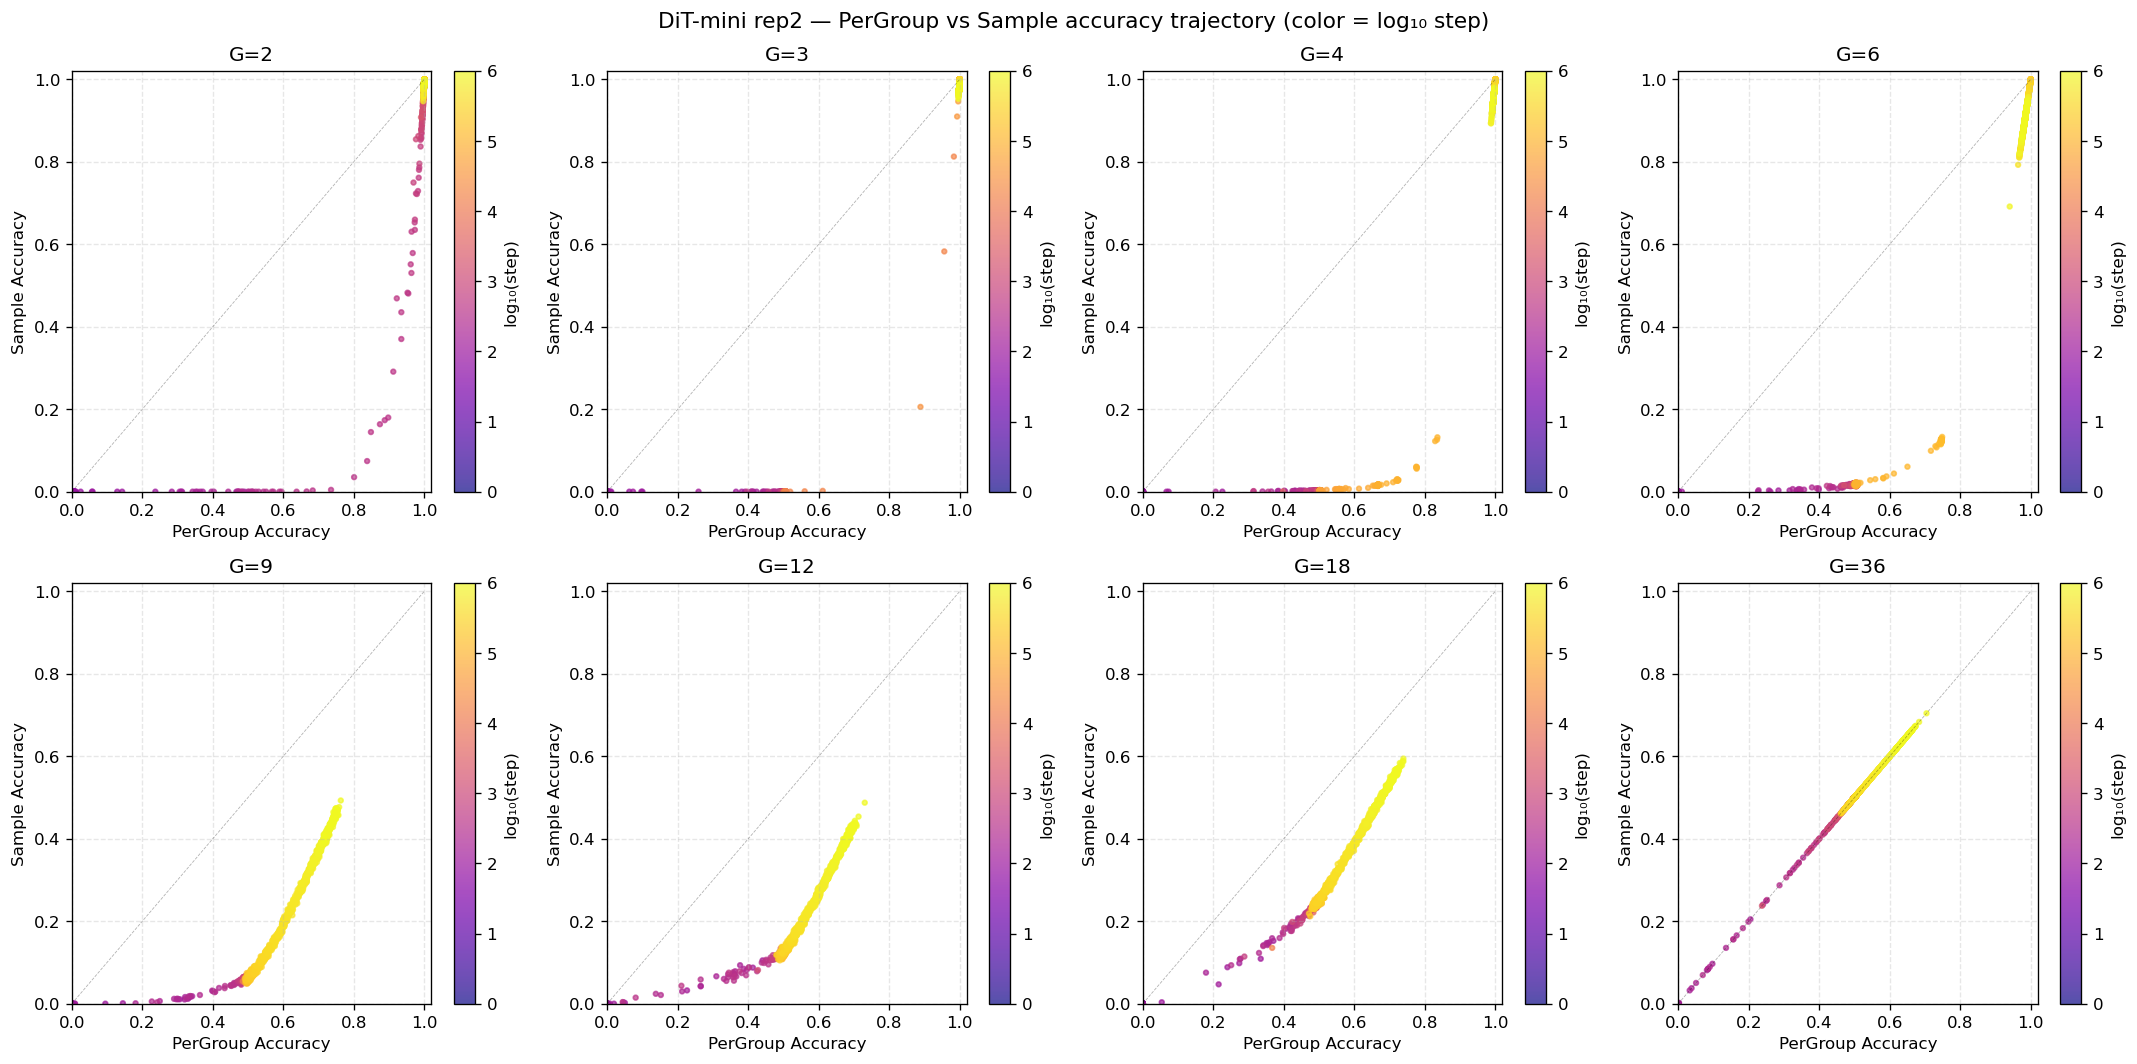

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('DiT-mini rep2 — PerGroup vs Sample accuracy trajectory (color = log₁₀ step)', fontsize=13)

for ax, g in zip(axes.flat, G_VALUES):
    if g not in all_data:
        ax.set_visible(False); continue
    d = all_data[g]
    if 'Eval/PerGroup_Accuracy' not in d or 'Eval/Sample_Accuracy' not in d:
        ax.set_title(f'G={g} (missing)'); continue

    steps_ga, ga = d['Eval/PerGroup_Accuracy']
    steps_sa, sa = d['Eval/Sample_Accuracy']
    common = np.intersect1d(steps_ga, steps_sa)
    ga_c   = ga[np.isin(steps_ga, common)]
    sa_c   = sa[np.isin(steps_sa, common)]
    log_t  = np.log10(common.clip(1))

    sc = ax.scatter(ga_c, sa_c, c=log_t, cmap='plasma', s=8, alpha=0.7)
    ax.set_xlabel('PerGroup Accuracy'); ax.set_ylabel('Sample Accuracy')
    ax.set_title(f'G={g}')
    ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
    ax.plot([0,1],[0,1],'k--',lw=0.5,alpha=0.3)
    ax.grid(True, ls='--', alpha=0.3)
    plt.colorbar(sc, ax=ax, label='log₁₀(step)')

plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(os.path.join(OUTDIR, 'group_vs_sample_acc_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()